In [1]:
# 7-12-2026

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
descriptors = pd.read_csv("../encoder-inputs/domain_descriptions.csv")
descriptors

,domain_id,vpd_mean,vpd_std,vpd_p90,ws10_mean,ws10_std,ws10_p90,t2m_max_mean,t2m_max_std,t2m_max_p90,...,swvl4_p90,gwis_ba_mean,gwis_ba_std,gwis_ba_p90,cams_frpfire_mean,cams_frpfire_std,cams_frpfire_p90,fire_sparsity,land_cover_diversity,fire_season_length
0,0,11.229313,5.895861,19.746270,2.516127,1.052111,3.968697,302.43317,4.790887,307.46002,...,0.479085,547.384100,1932.25460,1112.033700,0.067789,0.469590,0.097816,0.081824,0.728328,6
1,1,6.742952,3.144529,10.522034,1.406203,0.511182,2.132592,301.80650,4.735351,305.51370,...,0.499585,338.661650,1157.09030,705.891970,0.063071,0.392797,0.108795,0.013560,0.218936,7
2,2,21.599873,10.565010,36.654785,4.066474,0.951055,5.291819,303.89624,6.380806,311.61792,...,0.257699,3360.493400,8181.07230,8625.163000,0.162555,0.925012,0.219152,0.032987,0.602900,7
3,3,4.211150,2.716757,7.958644,3.166607,1.505368,5.099028,286.08792,10.954839,299.41890,...,0.411259,328.766850,739.65440,901.446350,0.041860,0.274789,0.000000,0.001419,0.365885,3
4,4,2.564834,3.033652,6.938553,3.300411,1.380530,5.114551,273.42078,16.251247,293.80110,...,0.447848,669.052060,2307.77000,1315.654900,0.185203,1.571907,0.090595,0.007227,0.615066,5
5,5,10.265495,5.699432,17.502420,2.046542,0.978449,3.276847,301.65985,5.860431,307.49870,...,0.491258,615.784000,2284.54270,1215.513500,0.141646,0.628370,0.270441,0.058533,0.560294,4
6,6,3.370416,3.105505,7.804835,3.172674,1.288420,4.654522,280.81445,12.255744,296.83127,...,0.394887,558.122500,2520.26320,715.896240,0.287090,2.909752,0.000000,0.003038,0.626834,4
7,7,11.621094,8.784235,24.302675,3.065614,1.245384,4.709380,295.90033,8.041678,307.00922,...,0.286967,513.446900,1531.67580,1095.658200,0.117847,0.972292,0.076211,0.004830,0.655366,3
8,8,7.512378,2.146205,10.056996,1.712309,1.128670,3.099993,302.63660,2.228121,305.12260,...,0.488031,328.441350,895.73500,747.977050,0.100920,0.937725,0.149864,0.019789,0.553258,5
9,9,3.658946,1.855246,6.112502,3.419243,1.666298,5.511101,287.73157,4.825871,294.05838,...,0.401618,1132.007300,4253.38570,1966.245800,0.543724,5.499713,0.000000,0.002421,0.625943,2


In [4]:
embeddings = pd.read_csv("domain_embeddings_v4.csv")
embeddings

,domain_id,e_0,e_1,e_2,e_3,e_4,e_5,e_6,e_7,e_8,src_bias,tgt_bias
0,0,0.044920,-0.140614,-0.092586,0.038657,0.091209,0.044721,-0.177195,0.017328,0.141784,0.204292,-0.017042
1,1,0.044615,-0.182949,-0.102645,0.036313,0.095344,0.107567,-0.248821,-0.000363,0.227570,0.176388,0.026637
2,2,0.065594,-0.110857,-0.039893,0.000854,0.076925,0.008618,-0.111971,-0.082349,0.096454,0.221703,-0.044998
3,4,0.081379,-0.068263,-0.103002,-0.023489,0.136152,0.028229,-0.148741,-0.059863,0.195213,0.231726,-0.063666
4,5,0.058112,-0.131804,-0.096756,0.065104,0.096903,0.066202,-0.164116,0.035039,0.129189,0.204279,-0.007497
5,6,0.031337,-0.078988,-0.079885,-0.028435,0.096454,0.022641,-0.151283,-0.107068,0.188521,0.203711,-0.052326
6,7,0.014070,-0.052960,-0.034756,-0.003813,0.026460,0.006066,-0.144582,-0.040931,0.106742,0.192011,-0.040780
7,8,0.006491,-0.177796,-0.116224,0.055101,0.083911,0.038436,-0.204769,-0.027186,0.193486,0.194318,0.001937
8,11,0.035975,-0.159781,-0.092753,0.021536,0.060885,0.046934,-0.127037,0.082622,0.108953,0.201887,-0.013454
9,12,0.207878,-0.076214,-0.010489,-0.033233,0.112294,0.160409,-0.162571,0.014760,0.106880,0.202830,-0.032079


In [5]:
# corr matrix between embedding dims and raw descriptors
merged_full = embeddings.merge(descriptors, on="domain_id", how="inner")

emb_cols = [c for c in embeddings.columns if c.startswith("e_")]
desc_cols = [c for c in descriptors.columns if c != "domain_id"]

corr_matrix = merged_full[emb_cols + desc_cols].corr(method="spearman").loc[emb_cols, desc_cols]
corr_matrix

,vpd_mean,vpd_std,vpd_p90,ws10_mean,ws10_std,ws10_p90,t2m_max_mean,t2m_max_std,t2m_max_p90,ndvi_mean,...,swvl4_p90,gwis_ba_mean,gwis_ba_std,gwis_ba_p90,cams_frpfire_mean,cams_frpfire_std,cams_frpfire_p90,fire_sparsity,land_cover_diversity,fire_season_length
e_0,0.343621,0.390680,0.390985,0.140107,-0.047823,0.119022,0.292895,0.092131,0.426738,-0.284339,...,-0.008098,0.401070,0.376318,0.415126,0.268755,0.016043,0.291743,-0.003514,-0.465241,-0.159285
e_1,-0.168831,0.229641,0.032850,0.373568,0.297785,0.368984,-0.633919,0.845378,-0.166998,-0.582582,...,-0.316119,-0.123606,-0.064629,-0.188694,-0.254393,0.096409,-0.682722,-0.618946,0.104966,0.051787
e_2,0.598167,0.714897,0.651337,0.290756,-0.086325,0.190833,0.292895,0.010542,0.569442,-0.385180,...,-0.643086,0.238197,0.255615,0.220779,-0.272116,-0.218029,-0.143425,-0.073186,0.141329,0.319983
e_3,-0.072574,-0.382429,-0.228724,-0.685256,-0.517189,-0.684645,0.386707,-0.729870,-0.021849,0.835600,...,0.501299,-0.244920,-0.262032,-0.174637,0.023988,-0.204584,0.542049,0.677617,0.031933,-0.085057
e_4,-0.287395,-0.247976,-0.287395,0.083270,0.075019,0.083575,-0.176165,0.404431,-0.138273,-0.071352,...,0.327731,-0.235141,-0.264171,-0.284339,-0.225974,-0.204889,-0.196789,-0.411459,-0.446295,0.091334
e_5,-0.126662,-0.240947,-0.208251,-0.457296,-0.352788,-0.460351,0.241253,-0.176776,0.016043,0.442628,...,0.480519,-0.441100,-0.488770,-0.391597,-0.320703,-0.522689,0.149694,0.072880,-0.614362,0.075641
e_6,0.354622,0.400153,0.393430,0.260504,-0.149274,0.181971,0.203667,-0.120550,0.256226,-0.256226,...,-0.287395,0.862185,0.886020,0.821849,0.774790,0.567303,0.417890,0.203667,0.175248,-0.325632
e_7,0.479297,0.269977,0.380290,-0.318869,-0.438350,-0.427655,0.621390,-0.600000,0.487242,0.322842,...,0.035600,0.141024,0.029794,0.271199,-0.224752,-0.607028,0.538838,0.713675,-0.083575,-0.043470
e_8,-0.793125,-0.790985,-0.827349,-0.301451,0.034989,-0.229030,-0.434072,0.190222,-0.665393,0.495798,...,0.638503,-0.536440,-0.512605,-0.587166,-0.258060,-0.104354,-0.202599,-0.117494,0.128189,0.048178


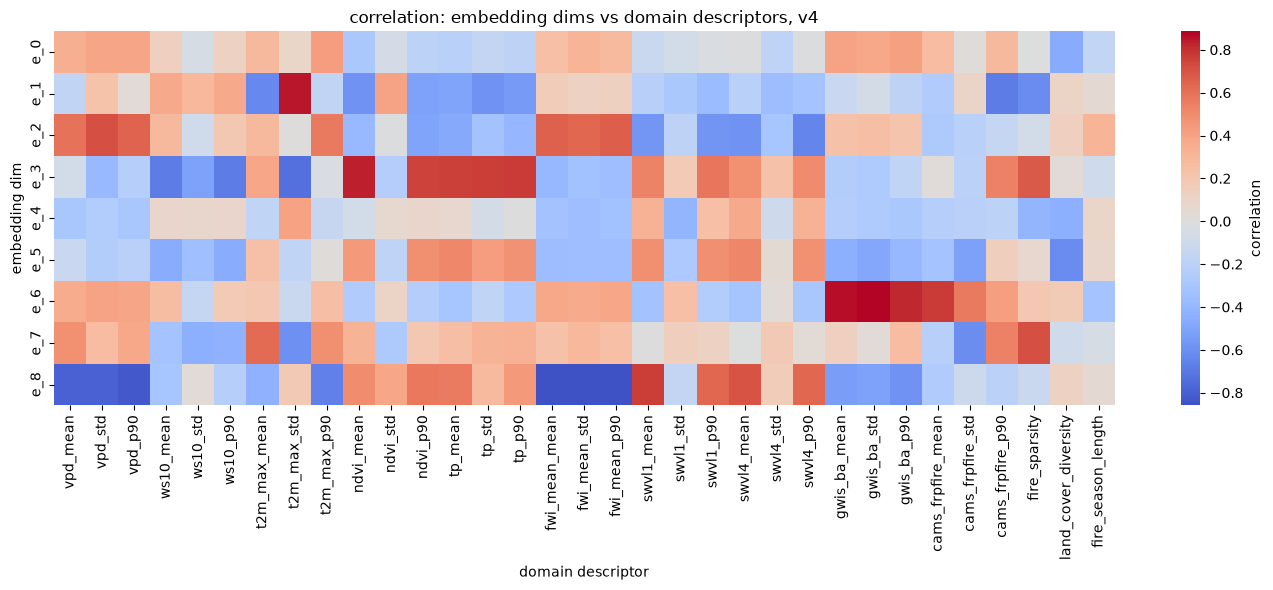

In [6]:
plt.figure(figsize=(14, 6))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False, cbar_kws={"label": "correlation"})
plt.xlabel("domain descriptor")
plt.ylabel("embedding dim")
plt.title("correlation: embedding dims vs domain descriptors, v4")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [8]:
avg_abs_corr = corr_matrix.abs().mean(axis=1).sort_values(ascending=False)
avg_abs_corr

e_8    0.458367
e_3    0.414674
e_2    0.370035
e_6    0.342095
e_5    0.341227
e_1    0.321718
e_7    0.292762
e_4    0.221204
e_0    0.211797
dtype: float64

In [9]:
atmospheric_cols = ["vpd_mean", "vpd_std", "vpd_p90", "ws10_mean", "ws10_std", "ws10_p90",
                     "t2m_max_mean", "t2m_max_std", "t2m_max_p90", "tp_mean", "tp_std", "tp_p90"]

ground_cols = ["ndvi_mean", "ndvi_std", "ndvi_p90", "swvl1_mean", "swvl1_std", "swvl1_p90",
               "swvl4_mean", "swvl4_std", "swvl4_p90", "land_cover_diversity"]

fire_cols = ["fwi_mean_mean", "fwi_mean_std", "fwi_mean_p90", "gwis_ba_mean", "gwis_ba_std", "gwis_ba_p90",
             "cams_frpfire_mean", "cams_frpfire_std", "cams_frpfire_p90", "fire_sparsity", "fire_season_length"]

In [ ]:
branch_cols = {
    "atmospheric": atmospheric_cols,
    "ground": ground_cols,
    "fire": fire_cols
}

dim_to_branch = {
    "e_0": "atmospheric", "e_1": "atmospheric", "e_2": "atmospheric",
    "e_3": "ground", "e_4": "ground", "e_5": "ground",
    "e_6": "fire", "e_7": "fire", "e_8": "fire"
}

In [11]:
rows = []
for dim, own_branch in dim_to_branch.items():
    own_cols = branch_cols[own_branch]
    other_cols = [c for c in corr_matrix.columns if c not in own_cols]

    within = corr_matrix.loc[dim, own_cols].abs().mean()
    outside = corr_matrix.loc[dim, other_cols].abs().mean()

    rows.append({"dim": dim, "branch": own_branch, "within": within, "outside": outside, "gap": within - outside})

separation_df = pd.DataFrame(rows).sort_values("gap", ascending=False)
separation_df

,dim,branch,within,outside,gap
6,e_6,fire,0.544112,0.241086,0.303026
1,e_1,atmospheric,0.395798,0.279387,0.116411
5,e_5,ground,0.401650,0.314955,0.086695
0,e_0,atmospheric,0.233486,0.199403,0.034083
4,e_4,ground,0.244492,0.211079,0.033413
3,e_3,ground,0.437280,0.404845,0.032435
2,e_2,atmospheric,0.383779,0.362181,0.021598
7,e_7,fire,0.304330,0.286978,0.017351
8,e_8,fire,0.448786,0.463157,-0.014371


In [ ]:
print("avg within:", separation_df["within"].mean())
print("avg outside:", separation_df["outside"].mean())
# even more highly correlated with other branches

avg within: 0.3770792674691402
avg outside: 0.3070081172790641


In [13]:
#hardest source domains = lowest avg row in true matrix, compare vs lowest src bias
# hardest target domains = lowest avg col in true matrix, compare vs lowest tgt bias

In [14]:
from scipy.stats import kendalltau

In [15]:
transfer_matrix = pd.read_csv("../transfer-matrix/rf_transfer_matrix.csv")
transfer_matrix.set_index("Unnamed: 0", inplace=True)
transfer_matrix.index.name = None
transfer_matrix.index = transfer_matrix.index.astype(int)
transfer_matrix.columns = transfer_matrix.columns.astype(int)

embeddings = pd.read_csv("domain_embeddings_v4.csv")

In [16]:
# mask diagonal so self transfer doesnt skew the avg
matrix_no_diag = transfer_matrix.copy()
np.fill_diagonal(matrix_no_diag.values, np.nan)

# row avg = domain as source, avg transfer to everyone else
row_avg = matrix_no_diag.mean(axis=1, skipna=True)
row_avg.name = "row_avg_src_quality"

# col avg = domain as target, avg transfer received from everyone else
col_avg = matrix_no_diag.mean(axis=0, skipna=True)
col_avg.name = "col_avg_tgt_quality"

quality_df = pd.concat([row_avg, col_avg], axis=1)
quality_df.index.name = "domain_id"
quality_df.reset_index(inplace=True)

In [17]:
merged = quality_df.merge(embeddings[["domain_id", "src_bias", "tgt_bias"]], on="domain_id", how="inner")
merged

,domain_id,row_avg_src_quality,col_avg_tgt_quality,src_bias,tgt_bias
0,0,0.126290,0.151128,0.204292,-0.017042
1,1,0.060158,0.160943,0.176388,0.026637
2,2,0.128974,0.074074,0.221703,-0.044998
3,4,0.145026,0.064597,0.231726,-0.063666
4,5,0.145435,0.150446,0.204279,-0.007497
5,6,0.123824,0.077961,0.203711,-0.052326
6,7,0.093909,0.098424,0.192011,-0.040780
7,8,0.091856,0.152708,0.194318,0.001937
8,11,0.136427,0.126173,0.201887,-0.013454
9,12,0.073347,0.041782,0.202830,-0.032079


In [ ]:
src_tau, _ = kendalltau(merged["row_avg_src_quality"], merged["src_bias"])
tgt_tau, _ = kendalltau(merged["col_avg_tgt_quality"], merged["tgt_bias"])

print(f"source: row avg transfer vs src bias, kendal tau {src_tau:.4f}")
print(f"target: col avg transfer vs tgtbias, kendall tau {tgt_tau:.4f}")
# avg 0.5722

source: row avg transfer vs src bias, kendal tau 0.5437
target: col avg transfer vs tgtbias, kendall tau 0.6007


In [ ]:
from scipy.spatial.distance import cdist

In [21]:
embeddings = pd.read_csv("domain_embeddings_v4.csv")
emb_cols = [c for c in embeddings.columns if c.startswith("e_")]

emb_matrix = embeddings[emb_cols].values

In [22]:
dist_matrix = cdist(emb_matrix, emb_matrix, metric="euclidean")

# negate so closer = higher value
dist_df = pd.DataFrame(
    -dist_matrix,
    index=embeddings["domain_id"],
    columns=embeddings["domain_id"]
)
dist_df

domain_id,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
domain_id,,,,,,,,,,,,,,,,,,,,,
0,-0.000000,-0.136632,-0.152547,-0.149830,-0.045888,-0.165802,-0.158605,-0.095896,-0.097581,-0.240578,...,-0.089083,-0.120262,-0.158772,-0.074194,-0.108090,-0.316126,-0.211809,-0.250951,-0.148676,-0.109221
1,-0.136632,-0.000000,-0.252197,-0.201603,-0.153239,-0.212914,-0.257308,-0.103677,-0.203910,-0.276930,...,-0.190257,-0.215741,-0.251932,-0.172419,-0.205736,-0.325842,-0.295290,-0.270966,-0.240177,-0.111723
2,-0.152547,-0.252197,-0.000000,-0.148802,-0.170710,-0.125925,-0.107206,-0.196852,-0.189254,-0.244667,...,-0.128896,-0.109845,-0.078075,-0.168468,-0.119604,-0.340595,-0.229512,-0.192610,-0.141337,-0.227812
4,-0.149830,-0.201603,-0.148802,-0.000000,-0.170444,-0.084052,-0.174745,-0.176069,-0.216329,-0.237323,...,-0.173726,-0.155547,-0.132948,-0.204015,-0.171112,-0.301071,-0.271263,-0.149330,-0.115043,-0.204943
5,-0.045888,-0.153239,-0.170710,-0.170444,-0.000000,-0.195750,-0.178844,-0.125927,-0.094361,-0.229468,...,-0.115723,-0.152369,-0.183301,-0.068605,-0.136074,-0.318459,-0.206568,-0.274396,-0.167757,-0.135504
6,-0.165802,-0.212914,-0.125925,-0.084052,-0.195750,-0.000000,-0.141065,-0.168382,-0.232311,-0.277270,...,-0.172765,-0.121689,-0.096106,-0.212152,-0.147981,-0.338584,-0.300559,-0.120018,-0.125355,-0.202760
7,-0.158605,-0.257308,-0.107206,-0.174745,-0.178844,-0.141065,-0.000000,-0.203553,-0.185285,-0.272344,...,-0.119894,-0.074591,-0.078628,-0.181378,-0.069374,-0.339066,-0.244959,-0.238474,-0.098545,-0.198673
8,-0.095896,-0.103677,-0.196852,-0.176069,-0.125927,-0.168382,-0.203553,-0.000000,-0.169468,-0.310777,...,-0.152417,-0.151514,-0.191361,-0.133656,-0.151028,-0.369598,-0.282983,-0.235146,-0.203088,-0.101159
11,-0.097581,-0.203910,-0.189254,-0.216329,-0.094361,-0.232311,-0.185285,-0.169468,-0.000000,-0.260179,...,-0.124739,-0.163288,-0.199636,-0.062569,-0.142548,-0.361394,-0.188930,-0.328380,-0.189229,-0.167426


In [ ]:
# dist_df.to_csv("embedding_matrix_v4.csv")

In [24]:
predicted_T4 = pd.read_csv("../training/predicted_transfer_matrix_v4.csv")
predicted_T4.set_index("Unnamed: 0", inplace=True)
predicted_T4.index.name = None
predicted_T4.index = predicted_T4.index.astype(int)
predicted_T4.columns = predicted_T4.columns.astype(int)
predicted_T4.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.187250,0.212261,0.136024,0.118177,0.194689,0.124477,0.138357,0.197033,0.181316,0.114335,...,0.181668,0.168882,0.138788,0.267368,0.151536,0.077980,0.128121,0.139860,0.137399,0.144191
1,0.140677,0.203025,0.067787,0.072078,0.145408,0.078730,0.069400,0.167576,0.121355,0.067618,...,0.125502,0.108896,0.072622,0.215240,0.092988,0.043839,0.057884,0.101510,0.073914,0.115734
2,0.181390,0.184737,0.176705,0.135895,0.185064,0.153520,0.169430,0.184889,0.172432,0.129762,...,0.190400,0.188690,0.175312,0.261902,0.166325,0.079322,0.137719,0.183149,0.156938,0.121633
4,0.192235,0.217720,0.164587,0.168061,0.195178,0.172336,0.160411,0.202663,0.171474,0.143325,...,0.186857,0.186584,0.173756,0.258685,0.161375,0.114706,0.126835,0.207971,0.173703,0.141553
5,0.185131,0.207434,0.130140,0.111562,0.196782,0.113636,0.131514,0.190359,0.181921,0.119544,...,0.176199,0.160116,0.130384,0.268153,0.144690,0.076487,0.130301,0.127530,0.131348,0.137746


In [25]:
diff = abs((predicted_T4 - predicted_T4.T).to_numpy())
np.fill_diagonal(diff, np.nan)
avg_asymmetry = np.nanmean(diff)
avg_asymmetry

np.float64(0.03625912863582888)